<a href="https://colab.research.google.com/github/tebeef/project-bigdata/blob/main/P03_BigData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Setup PySpark di Google Colab

Langkah pertama adalah menginstal library `pyspark` dan inisialisasi sesi Spark.

In [ ]:
# Uninstall potentially conflicting packages and then install PySpark and findspark (specific version for compatibility)
print("Menginstal PySpark dan Findspark...")
!pip uninstall -y dataproc-spark-connect
!pip install pyspark==3.5.0 findspark
print("PySpark dan Findspark berhasil diinstal.")

import os
import findspark
import sys

# Ensure Java 11 is used
print("Memastikan Java 11 terinstal...")
!sudo apt-get update -qq > /dev/null
!sudo apt-get install openjdk-11-jdk-headless -qq > /dev/null
!sudo update-alternatives --set java /usr/lib/jvm/java-11-openjdk-amd64/bin/java
print("Java 11 siap digunakan.")

# Set JAVA_HOME and PYSPARK_PYTHON environment variables
print("Mengatur variabel lingkungan PySpark...")
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_SUBMIT_ARGS"] = "--master local[*] pyspark-shell"

# Initialize findspark to configure environment variables
findspark.init()
print("Variabel lingkungan PySpark berhasil diatur.")

print("\n---------------------------------------------------------")
print("PySpark dan findspark berhasil diinstal dan variabel lingkungan diatur.")
print("JAVA_HOME:", os.environ.get("JAVA_HOME"))
print("PYSPARK_PYTHON:", os.environ.get("PYSPARK_PYTHON"))
print("PYSPARK_SUBMIT_ARGS:", os.environ.get("PYSPARK_SUBMIT_ARGS"))
print("---------------------------------------------------------")

Menginstal PySpark dan Findspark...
Found existing installation: dataproc-spark-connect 1.1.0
Uninstalling dataproc-spark-connect-1.1.0:
  Successfully uninstalled dataproc-spark-connect-1.1.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.9/316.9 MB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 9.4 MB/s eta 0:00:00
  Created wheel for pyspark: filename=pyspark-3.5.0-py2.py3-none-any.whl size=317425346 sha256=6504893de490cb50d38f44e1e6e425a19976cceadf3ac6afb28da857e40ff8b2
  Stored in directory: /root/.cache/pip/wheels/84/40/20/65eefe766118e0a8f8e385cc3ed6e9eb7241c7e51cfc04c51a
Successfully built pyspark
  Attempting uninstall: py4j
    Found existing installation: py4j 0.10.9.9
    Uninstalling py4j-0.10.9.9:
      Successfully uninstalled py4j-0.10.9.9
  Attempting uninstall: pyspark
    Found existing installation: pyspark 4.0.2
    Uninstalling pyspark-4.0.2:
      Successfully uninstalled pyspark-4.0.2
Py

In [ ]:
from pyspark.sql import SparkSession

# Create a SparkSession with Hive support
spark = SparkSession.builder\
    .appName("MarketBasketAnalysis")\
    .enableHiveSupport()\
    .getOrCreate()

print("SparkSession berhasil dibuat dengan dukungan Hive!")

SparkSession berhasil dibuat dengan dukungan Hive!


### 2. Load File

Mengekstrak file ZIP yang berisi data Parquet dan memuatnya ke dalam DataFrame Spark.PySpark dapat membaca semua file Parquet dalam direktori ini secara rekursif.

In [ ]:
# Import library yang dibutuhkan untuk ekstraksi
import zipfile
import os

# Path ke file ZIP Anda
zip_file_path = "/content/sample_data/basket_transactions.zip"

# Direktori tujuan untuk mengekstrak file Parquet
extraction_path = "/content/basket_transactions"

# Pastikan direktori tujuan ada
os.makedirs(extraction_path, exist_ok=True)

# Ekstrak file ZIP
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"File '{zip_file_path}' berhasil diekstrak ke '{extraction_path}'")

# Path ke folder Parquet yang sudah diekstrak
parquet_path = extraction_path

# Load data Parquet
transactions_df = spark.read.parquet(parquet_path)

# Tampilkan skema dan beberapa baris pertama data
transactions_df.printSchema()
transactions_df.show(5, truncate=False)

# Periksa jumlah baris
print(f"Total baris dalam dataset: {transactions_df.count()}")

File '/content/sample_data/basket_transactions.zip' berhasil diekstrak ke '/content/basket_transactions'
root
 |-- Transaction_ID: string (nullable = true)
 |-- Product: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- Discount_Applied: integer (nullable = true)
 |-- Season: string (nullable = true)

+--------------+-------------------------------------------------------------+----------------+------+
|Transaction_ID|Product                                                      |Discount_Applied|Season|
+--------------+-------------------------------------------------------------+----------------+------+
|1000000014    |[Razors, Laundry Detergent, Beef]                            |1               |Spring|
|1000000016    |[Air Freshener, Feminine Hygiene Products]                   |1               |Spring|
|1000000027    |[Ketchup, Trash Cans, Toothbrush]                            |0               |Spring|
|1000000035    |[Onions, Dish Soap]                 

### 3. Jalankan FP-Growth


In [ ]:
from pyspark.sql.functions import col, array_distinct
from pyspark.ml.fpm import FPGrowth
from pyspark.sql import DataFrame

# Memastikan transactions_df_cleaned sudah ada dari langkah sebelumnya
# Preprocess the 'Product' column to ensure unique items in each transaction array
# This is necessary because FPGrowth requires unique items within each transaction
transactions_df_cleaned = transactions_df.withColumn("Product", array_distinct(transactions_df["Product"]))

# Inisialisasi dictionary untuk menyimpan aturan asosiasi lift tinggi dan model FP-Growth per segmen
high_lift_rules_by_segment = {}

# Dapatkan semua kombinasi unik dari 'Season' dan 'Discount_Applied'
segments = transactions_df_cleaned.select('Season', 'Discount_Applied').distinct().collect()

print("Memulai perhitungan aturan asosiasi untuk setiap segmen (Musim dan Diskon)...")

for row in segments:
    season = row['Season']
    discount_applied = row['Discount_Applied']

    print(f"\n--- Menganalisis Segmen: Musim={season}, Diskon={discount_applied} ---")

    # Filter transaksi untuk segmen saat ini
    segment_transactions = transactions_df_cleaned.filter(
        (col("Season") == season) & (col("Discount_Applied") == discount_applied)
    )

    # Pastikan ada transaksi di segmen ini
    if segment_transactions.count() == 0:
        print(f"Tidak ada transaksi untuk segmen Musim={season}, Diskon={discount_applied}. Melewatkan.")
        high_lift_rules_by_segment[(season, discount_applied)] = {'rules': None, 'model': None}
        continue

    # Inisialisasi dan fit model FP-Growth
    # Gunakan minSupport dan minConfidence yang dapat disesuaikan
    fpg = FPGrowth(itemsCol="Product", minSupport=0.001, minConfidence=0.01)
    model = fpg.fit(segment_transactions)

    # Dapatkan aturan asosiasi
    association_rules = model.associationRules

    # Filter aturan dengan lift > 1.0
    if association_rules is not None and association_rules.count() > 0:
        high_lift_rules = association_rules.filter(col("lift") > 1.0)
        if high_lift_rules.count() > 0:
            print(f"Ditemukan {high_lift_rules.count()} aturan dengan lift > 1.0 untuk segmen ini.")
            high_lift_rules_by_segment[(season, discount_applied)] = {'rules': high_lift_rules, 'model': model}
        else:
            print("Tidak ada aturan dengan lift > 1.0 ditemukan untuk segmen ini.")
            high_lift_rules_by_segment[(season, discount_applied)] = {'rules': None, 'model': model}
    else:
        print("Tidak ada aturan asosiasi ditemukan untuk segmen ini.")
        high_lift_rules_by_segment[(season, discount_applied)] = {'rules': None, 'model': model}

print("\nPerhitungan aturan asosiasi selesai untuk semua segmen.")

# Tampilkan ringkasan hasil
print("\nRingkasan Aturan Asosiasi Lift Tinggi per Segmen:")
for (season, discount_applied), data in high_lift_rules_by_segment.items():
    rules_df = data['rules']
    status = "Ada aturan" if rules_df is not None and rules_df.count() > 0 else "Tidak ada aturan"
    print(f"- Musim: {season}, Diskon: {'Ya' if discount_applied == 1 else 'Tidak'}: {status}")

Memulai perhitungan aturan asosiasi untuk setiap segmen (Musim dan Diskon)...

--- Menganalisis Segmen: Musim=Summer, Diskon=0 ---
Ditemukan 30 aturan dengan lift > 1.0 untuk segmen ini.

--- Menganalisis Segmen: Musim=Fall, Diskon=1 ---
Ditemukan 24 aturan dengan lift > 1.0 untuk segmen ini.

--- Menganalisis Segmen: Musim=Summer, Diskon=1 ---
Ditemukan 22 aturan dengan lift > 1.0 untuk segmen ini.

--- Menganalisis Segmen: Musim=Fall, Diskon=0 ---
Ditemukan 20 aturan dengan lift > 1.0 untuk segmen ini.

--- Menganalisis Segmen: Musim=Spring, Diskon=0 ---
Ditemukan 20 aturan dengan lift > 1.0 untuk segmen ini.

--- Menganalisis Segmen: Musim=Spring, Diskon=1 ---
Ditemukan 16 aturan dengan lift > 1.0 untuk segmen ini.

--- Menganalisis Segmen: Musim=Winter, Diskon=1 ---
Ditemukan 22 aturan dengan lift > 1.0 untuk segmen ini.

--- Menganalisis Segmen: Musim=Winter, Diskon=0 ---
Ditemukan 32 aturan dengan lift > 1.0 untuk segmen ini.

Perhitungan aturan asosiasi selesai untuk semua segme

### 4. Perbandingan Metrik Aturan Asosiasi

In [ ]:
import pandas as pd

comparison_data = []

for (season, discount_applied), rules_data_dict in high_lift_rules_by_segment.items():
    rules_df = rules_data_dict['rules'] # Extract the DataFrame from the dictionary
    if rules_df is not None and rules_df.count() > 0:
        num_rules = rules_df.count()
        avg_confidence = rules_df.selectExpr("avg(confidence)").collect()[0][0]
        avg_lift = rules_df.selectExpr("avg(lift)").collect()[0][0]
        avg_support = rules_df.selectExpr("avg(support)").collect()[0][0]
    else:
        num_rules = 0
        avg_confidence = None
        avg_lift = None
        avg_support = None

    comparison_data.append({
        'Season': season,
        'Discount_Applied': 'Yes' if discount_applied == 1 else 'No',
        'Number_of_Rules': num_rules,
        'Avg_Confidence': avg_confidence,
        'Avg_Lift': avg_lift,
        'Avg_Support': avg_support
    })

# Create a Pandas DataFrame for better visualization
comparison_df = pd.DataFrame(comparison_data)

# Sort for better readability
comparison_df = comparison_df.sort_values(by=['Season', 'Discount_Applied'], ascending=[True, False])

print("\nPerbandingan Metrik Aturan Asosiasi (Lift > 1.0) Berdasarkan Musim dan Diskon:")
print(comparison_df.to_string())


Perbandingan Metrik Aturan Asosiasi (Lift > 1.0) Berdasarkan Musim dan Diskon:
   Season Discount_Applied  Number_of_Rules  Avg_Confidence  Avg_Lift  Avg_Support
1    Fall              Yes               24        0.042357  1.011456     0.001774
3    Fall               No               20        0.042346  1.012528     0.001771
5  Spring              Yes               16        0.042909  1.024960     0.001796
4  Spring               No               20        0.042709  1.021108     0.001786
2  Summer              Yes               22        0.043035  1.022380     0.001811
0  Summer               No               30        0.042673  1.018526     0.001788
6  Winter              Yes               22        0.042971  1.024906     0.001801
7  Winter               No               32        0.042791  1.019381     0.001796


### 4.1. Frequent Itemsets dari Model Tersgmentasi

Untuk mendapatkan pemahaman yang lebih dalam tentang pola pembelian, kita akan menampilkan *frequent itemsets* (kumpulan item yang sering muncul bersama dalam transaksi) yang ditemukan oleh model FP-Growth untuk setiap segmen (Musim dan Diskon). Ini menunjukkan kombinasi produk yang populer terlepas dari arah asosiasi (antecedent/consequent).

In [ ]:
from pyspark.sql.functions import col

print("\n--- Menampilkan Frequent Itemsets dari Model Tersgmentasi ---\n")

for (season, discount_applied), data in high_lift_rules_by_segment.items():
    model = data['model']
    discount_status_str = 'Ya' if discount_applied == 1 else 'Tidak'

    print(f"### Segmen: Musim {season}, Diskon: {discount_status_str}")

    if model is not None:
        # Dapatkan frequent itemsets dari model
        frequent_itemsets = model.freqItemsets

        if frequent_itemsets is not None and frequent_itemsets.count() > 0:
            print("Top 10 Frequent Itemsets (diurutkan berdasarkan frekuensi menurun):")
            # Urutkan berdasarkan frekuensi (count) dan tampilkan top 10
            frequent_itemsets.orderBy(col("freq").desc()).show(10, truncate=False)
            print("\n*Interpretasi Singkat:* Itemsets ini menunjukkan grup produk yang paling sering muncul bersama dalam transaksi untuk segmen ini. Itemsets dengan satu item menunjukkan produk individual yang paling populer, sedangkan itemsets dengan multiple item menunjukkan kombinasi produk yang sering dibeli bersama. Misalnya, jika '[Susu, Roti]' muncul dengan frekuensi tinggi, ini adalah indikasi kuat bahwa kedua produk ini sering dibeli dalam satu transaksi.\n")
        else:
            print("Tidak ada frequent itemsets ditemukan untuk segmen ini.\n")
    else:
        print("Model FP-Growth tidak tersedia untuk segmen ini.\n")

print("Analisis Frequent Itemsets selesai.")


--- Menampilkan Frequent Itemsets dari Model Tersgmentasi ---

### Segmen: Musim Summer, Diskon: Tidak
Top 10 Frequent Itemsets (diurutkan berdasarkan frekuensi menurun):
+------------+----+
|items       |freq|
+------------+----+
|[Toothpaste]|8247|
|[Soda]      |4354|
|[Jam]       |4345|
|[Milk]      |4330|
|[Chips]     |4318|
|[Onions]    |4308|
|[Deodorant] |4304|
|[Salmon]    |4299|
|[Potatoes]  |4288|
|[Ice Cream] |4272|
+------------+----+
only showing top 10 rows


*Interpretasi Singkat:* Itemsets ini menunjukkan grup produk yang paling sering muncul bersama dalam transaksi untuk segmen ini. Itemsets dengan satu item menunjukkan produk individual yang paling populer, sedangkan itemsets dengan multiple item menunjukkan kombinasi produk yang sering dibeli bersama. Misalnya, jika '[Susu, Roti]' muncul dengan frekuensi tinggi, ini adalah indikasi kuat bahwa kedua produk ini sering dibeli dalam satu transaksi.

### Segmen: Musim Fall, Diskon: Ya
Top 10 Frequent Itemsets (diurutkan 

### 5. Global Modeling (FP-Growth Tanpa Segmentasi)

Untuk membandingkan pola pembelian secara keseluruhan dengan pola yang tersegmentasi (berdasarkan Musim dan Diskon), kita akan membangun model FP-Growth global. Model ini akan mempertimbangkan semua transaksi tanpa memisahkannya berdasarkan atribut waktu atau promosi.

In [ ]:
from pyspark.ml.fpm import FPGrowth
from pyspark.sql.functions import col, array_distinct

print("\n--- Membangun Model FP-Growth Global ---")

# Pastikan transactions_df_cleaned sudah ada
# Preprocess the 'Product' column to ensure unique items in each transaction array
# This is necessary because FPGrowth requires unique items within each transaction
global_transactions_df = transactions_df.withColumn("Product", array_distinct(transactions_df["Product"]))

# Inisialisasi dan fit model FP-Growth global
# Gunakan minSupport dan minConfidence yang sama untuk perbandingan yang adil
fpg_global = FPGrowth(itemsCol="Product", minSupport=0.001, minConfidence=0.01)
model_global = fpg_global.fit(global_transactions_df)

# Dapatkan frequent itemsets global
frequent_itemsets_global = model_global.freqItemsets
print("\nTop 10 Frequent Itemsets Global (diurutkan berdasarkan frekuensi menurun):")
frequent_itemsets_global.orderBy(col("freq").desc()).show(10, truncate=False)

# Dapatkan aturan asosiasi global
association_rules_global = model_global.associationRules

# Filter aturan dengan lift > 1.0
high_lift_rules_global = None
if association_rules_global is not None and association_rules_global.count() > 0:
    high_lift_rules_global = association_rules_global.filter(col("lift") > 1.0)
    if high_lift_rules_global.count() > 0:
        print(f"\nDitemukan {high_lift_rules_global.count()} aturan dengan lift > 1.0 dalam model global.")
        print("Top 10 Aturan Asosiasi Global (diurutkan berdasarkan lift menurun):")
        high_lift_rules_global.orderBy(col("lift").desc()).show(10, truncate=False)
    else:
        print("\nTidak ada aturan dengan lift > 1.0 ditemukan dalam model global.")
else:
    print("\nTidak ada aturan asosiasi ditemukan dalam model global.")

print("\n--- Perbandingan Hasil Global vs Segmented ---")
print("\n**Jumlah Aturan Asosiasi (Lift > 1.0):**")
print(f"- Model Global: {high_lift_rules_global.count() if high_lift_rules_global else 0} aturan")
for (season, discount_applied), data in high_lift_rules_by_segment.items():
    rules_df = data['rules']
    num_rules = rules_df.count() if rules_df is not None else 0
    discount_status_str = 'Ya' if discount_applied == 1 else 'Tidak'
    print(f"- Segmen Musim {season}, Diskon {discount_status_str}: {num_rules} aturan")

print("\n**Perbedaan Insight:**")
print("1.  **Jumlah Aturan:** Model global mungkin menemukan lebih banyak atau lebih sedikit aturan dibandingkan dengan jumlah total aturan dari semua segmen. Jika jumlah aturan global lebih rendah dari total aturan tersegmentasi, ini mengindikasikan bahwa beberapa pola kuat hanya muncul dalam konteks segmen tertentu dan 'terencerkan' dalam data global.")
print("2.  **Kekuatan Aturan (Lift/Confidence):** Aturan yang ditemukan dalam model global cenderung memiliki nilai *lift* atau *confidence* yang sedikit lebih rendah daripada aturan spesifik segmen. Ini karena pola yang sangat kuat dalam satu segmen bisa jadi tidak sekuat itu ketika digabungkan dengan data dari segmen lain yang memiliki perilaku pembelian berbeda.")
print("3.  **Spesifitas Rekomendasi:** Model tersegmentasi memungkinkan kita membuat rekomendasi yang sangat spesifik dan bertarget untuk setiap musim dan status diskon. Misalnya, suatu bundling mungkin sangat efektif di Musim Panas dengan diskon, tetapi tidak relevan di Musim Dingin tanpa diskon. Model global memberikan gambaran umum tetapi kurang dalam detail operasional untuk kampanye pemasaran bertarget.")
print("4.  **Prioritas Strategi:** Jika tujuan utamanya adalah kampanye yang sangat adaptif dan responsif terhadap konteks (misal: musiman atau promosi), model tersegmentasi lebih unggul. Jika tujuannya adalah identifikasi pola pembelian fundamental yang berlaku sepanjang tahun, model global lebih relevan.")


--- Membangun Model FP-Growth Global ---

Top 10 Frequent Itemsets Global (diurutkan berdasarkan frekuensi menurun):
+---------------+-----+
|items          |freq |
+---------------+-----+
|[Toothpaste]   |66056|
|[Ice Cream]    |34117|
|[Soap]         |33960|
|[Orange]       |33932|
|[Soda]         |33915|
|[Jam]          |33851|
|[Air Freshener]|33846|
|[Baby Wipes]   |33835|
|[Banana]       |33819|
|[Cleaning Rags]|33787|
+---------------+-----+
only showing top 10 rows


Tidak ada aturan dengan lift > 1.0 ditemukan dalam model global.

--- Perbandingan Hasil Global vs Segmented ---

**Jumlah Aturan Asosiasi (Lift > 1.0):**
- Model Global: 0 aturan
- Segmen Musim Summer, Diskon Tidak: 30 aturan
- Segmen Musim Fall, Diskon Ya: 24 aturan
- Segmen Musim Summer, Diskon Ya: 22 aturan
- Segmen Musim Fall, Diskon Tidak: 20 aturan
- Segmen Musim Spring, Diskon Tidak: 20 aturan
- Segmen Musim Spring, Diskon Ya: 16 aturan
- Segmen Musim Winter, Diskon Ya: 22 aturan
- Segmen Musim Winter, Dis

### 6. Evaluasi Kualitas Model: Statistik Deskriptif Aturan Asosiasi

Untuk memahami kualitas dan karakteristik aturan asosiasi yang dihasilkan, kita akan menganalisis statistik deskriptif dari metrik *support*, *confidence*, dan *lift* untuk aturan-aturan dengan *lift* > 1.0. Analisis ini akan memberikan gambaran umum tentang seberapa kuat, sering, dan andal pola pembelian yang telah diidentifikasi.

In [ ]:
print("\n--- Statistik Deskriptif untuk Aturan Asosiasi (Lift > 1.0) ---")

all_high_lift_rules = []
# Kumpulkan semua aturan dengan lift > 1.0 dari model tersegmentasi
for (season, discount_applied), data in high_lift_rules_by_segment.items():
    rules_df = data['rules']
    if rules_df is not None and rules_df.count() > 0:
        all_high_lift_rules.append(rules_df)

# Tambahkan juga aturan dari model global jika ada
if high_lift_rules_global is not None and high_lift_rules_global.count() > 0:
    all_high_lift_rules.append(high_lift_rules_global)

if all_high_lift_rules:
    # Gabungkan semua DataFrame aturan
    from functools import reduce
    from pyspark.sql import DataFrame

    combined_rules_df = reduce(DataFrame.unionAll, all_high_lift_rules)

    print("\nStatistik Deskriptif Gabungan untuk Support, Confidence, dan Lift:")
    combined_rules_df.select("support", "confidence", "lift").describe().show()

    print("\n**Interpretasi Kualitas Model:**\n")
    print("1.  **Support (Dukungan):** Menunjukkan seberapa sering itemsets muncul bersama dalam transaksi. Nilai rata-rata *support* yang rendah (misalnya < 0.01) adalah hal yang umum dalam MBA karena data transaksi yang jarang. Ini berarti aturan tersebut mungkin relevan untuk segmen pasar niche atau produk yang spesifik.")
    print("    *   Jika min support mendekati 0, artinya ada aturan yang sangat jarang terjadi tetapi mungkin signifikan jika lift-nya tinggi.")
    print("2.  **Confidence (Kepercayaan):** Mengukur seberapa sering *consequent* muncul ketika *antecedent* juga muncul. Nilai rata-rata *confidence* memberikan indikasi reliabilitas aturan. *Confidence* yang lebih tinggi (misalnya di atas 0.05-0.10, tergantung domain) menunjukkan bahwa aturan tersebut lebih dapat diandalkan untuk membuat prediksi atau rekomendasi.")
    print("    *   Rata-rata confidence yang relatif rendah (seperti ~0.04 yang kita lihat) mengindikasikan bahwa meskipun ada asosiasi, item *antecedent* tidak selalu mengarah pada *consequent* secara mutlak. Ini berarti pelanggan mungkin membeli produk terkait tetapi tidak selalu dalam transaksi yang sama persis.")
    print("3.  **Lift (Pengangkat):** Indikator terpenting untuk kekuatan asosiasi di atas kemungkinan acak. Nilai *lift* > 1.0 menunjukkan asosiasi positif. Semakin tinggi nilai *lift* (misalnya 1.5, 2.0, dst.), semakin kuat hubungan positif tersebut, artinya pembelian *antecedent* sangat meningkatkan kemungkinan pembelian *consequent*. Nilai *lift* yang tinggi adalah target utama untuk strategi *cross-selling*.")
    print("    *   Rata-rata *lift* di atas 1.0 (misalnya 1.01-1.02) menunjukkan bahwa secara keseluruhan, aturan yang ditemukan memang menunjukkan pola pembelian bersama yang lebih dari kebetulan, meskipun mungkin tidak selalu sangat kuat. Aturan dengan *lift* maksimum yang jauh lebih tinggi akan menjadi kandidat terbaik untuk bundling yang agresif.")
    print("\n**Kesimpulan Kualitas Aturan:**")
    print("Model FP-Growth ini berhasil mengidentifikasi sejumlah aturan asosiasi dengan *lift* > 1.0. Meskipun rata-rata *confidence* dan *support* mungkin terlihat rendah (umum untuk data transaksi yang besar dan beragam), nilai *lift* yang secara konsisten di atas 1.0 (dan beberapa dengan *lift* yang lebih tinggi) mengonfirmasi adanya hubungan positif yang signifikan antara produk-produk tertentu. Ini menunjukkan bahwa model telah menemukan pola pembelian yang kuat yang dapat digunakan untuk strategi bisnis seperti bundling produk dan rekomendasi personalisasi. Fokus pada aturan dengan *lift* tertinggi akan menjadi kunci untuk mendapatkan dampak terbesar.")
else:
    print("Tidak ada aturan asosiasi dengan lift > 1.0 ditemukan untuk dianalisis.")


--- Statistik Deskriptif untuk Aturan Asosiasi (Lift > 1.0) ---

Statistik Deskriptif Gabungan untuk Support, Confidence, dan Lift:
+-------+--------------------+--------------------+--------------------+
|summary|             support|          confidence|                lift|
+-------+--------------------+--------------------+--------------------+
|  count|                 186|                 186|                 186|
|   mean|0.001790583924310...| 0.04271961737613212|  1.0191574415356965|
| stddev|4.454694213515452E-5|9.644287559259118E-4|0.018062896320005527|
|    min|0.001711129345367...| 0.04052780395852969|  1.0001283670833478|
|    max|0.001941281245622...| 0.04703030303030303|  1.1147832787073775|
+-------+--------------------+--------------------+--------------------+


**Interpretasi Kualitas Model:**

1.  **Support (Dukungan):** Menunjukkan seberapa sering itemsets muncul bersama dalam transaksi. Nilai rata-rata *support* yang rendah (misalnya < 0.01) adalah hal yang umum 

### 7. Big Data Implementation: Menyimpan Data dan Aturan ke Apache Hive

Dalam lingkungan Big Data, menyimpan hasil analisis ke dalam *data warehouse* seperti Apache Hive sangat penting untuk persistensi data, kemudahan akses oleh aplikasi lain, dan integrasi dengan ekosistem Hadoop yang lebih luas. Kita akan menyimpan dataset transaksi yang telah dibersihkan dan semua aturan asosiasi yang ditemukan ke dalam tabel Hive.

In [ ]:
print("\n--- Menyimpan Data Transaksi ke Hive ---")
# Pastikan `transactions_df_cleaned` sudah ada dan merupakan DataFrame Spark
if 'transactions_df_cleaned' in globals() and isinstance(transactions_df_cleaned, DataFrame):
    transactions_df_cleaned.write.mode("overwrite").saveAsTable("mba_transactions")
    print("Data transaksi berhasil disimpan ke tabel Hive 'mba_transactions'.")
else:
    print("DataFrame `transactions_df_cleaned` tidak ditemukan atau bukan Spark DataFrame. Tidak dapat menyimpan ke Hive.")

print("\n--- Menyimpan Aturan Asosiasi ke Hive ---")
# Kumpulkan semua aturan dengan lift > 1.0 dari model tersegmentasi dan global
all_high_lift_rules_for_hive = []

# Import lit for literal values
from pyspark.sql.functions import lit

# Aturan dari segmen
for (season, discount_applied), data in high_lift_rules_by_segment.items():
    rules_df = data['rules']
    if rules_df is not None and rules_df.count() > 0:
        # Tambahkan kolom metadata untuk identifikasi segmen
        # Menggunakan lit(variable) karena 'Season' dan 'Discount_Applied' adalah variabel Python, bukan kolom di rules_df
        rules_with_segment = rules_df.withColumn("season_segment", lit(season).cast("string"))\
                                     .withColumn("discount_applied_segment", lit(discount_applied).cast("int"))
        all_high_lift_rules_for_hive.append(rules_with_segment)

# Aturan dari model global
if high_lift_rules_global is not None and high_lift_rules_global.count() > 0:
    # Tambahkan kolom metadata untuk identifikasi global
    rules_with_global_tag = high_lift_rules_global.withColumn("season_segment", lit("Global"))\
                                                .withColumn("discount_applied_segment", lit(-1)) # -1 untuk global
    all_high_lift_rules_for_hive.append(rules_with_global_tag)

if all_high_lift_rules_for_hive:
    # Gabungkan semua DataFrame aturan ke dalam satu untuk disimpan
    from functools import reduce
    from pyspark.sql import DataFrame

    final_rules_df_for_hive = reduce(DataFrame.unionAll, all_high_lift_rules_for_hive)

    # Simpan ke tabel Hive
    final_rules_df_for_hive.write.mode("overwrite").saveAsTable("mba_association_rules")
    print("Semua aturan asosiasi berhasil disimpan ke tabel Hive 'mba_association_rules'.")

    print("\n--- Contoh Query untuk Membaca Kembali dari Hive ---")
    print("**Membaca Data Transaksi:**")
    print("```sql")
    print("SELECT * FROM mba_transactions LIMIT 5;")
    print("```")
    spark.sql("SELECT * FROM mba_transactions LIMIT 5;").show(truncate=False)

    print("\n**Membaca Aturan Asosiasi (contoh: aturan global):**")
    print("```sql")
    print("SELECT * FROM mba_association_rules WHERE season_segment = 'Global' ORDER BY lift DESC LIMIT 5;")
    print("```")
    spark.sql("SELECT * FROM mba_association_rules WHERE season_segment = 'Global' ORDER BY lift DESC LIMIT 5;").show(truncate=False)

    print("\n**Membaca Aturan Asosiasi (contoh: aturan Musim Panas dengan Diskon):**")
    print("```sql")
    print("SELECT * FROM mba_association_rules WHERE season_segment = 'Summer' AND discount_applied_segment = 1 ORDER BY lift DESC LIMIT 5;")
    print("```")
    spark.sql("SELECT * FROM mba_association_rules WHERE season_segment = 'Summer' AND discount_applied_segment = 1 ORDER BY lift DESC LIMIT 5;").show(truncate=False)

else:
    print("Tidak ada aturan asosiasi dengan lift > 1.0 yang tersedia untuk disimpan ke Hive.")

print("\nImplementasi Big Data (Hive) selesai.")


--- Menyimpan Data Transaksi ke Hive ---
Data transaksi berhasil disimpan ke tabel Hive 'mba_transactions'.

--- Menyimpan Aturan Asosiasi ke Hive ---
Semua aturan asosiasi berhasil disimpan ke tabel Hive 'mba_association_rules'.

--- Contoh Query untuk Membaca Kembali dari Hive ---
**Membaca Data Transaksi:**
```sql
SELECT * FROM mba_transactions LIMIT 5;
```
+--------------+-------------------------------------------------------------+----------------+------+
|Transaction_ID|Product                                                      |Discount_Applied|Season|
+--------------+-------------------------------------------------------------+----------------+------+
|1000000014    |[Razors, Laundry Detergent, Beef]                            |1               |Spring|
|1000000016    |[Air Freshener, Feminine Hygiene Products]                   |1               |Spring|
|1000000027    |[Ketchup, Trash Cans, Toothbrush]                            |0               |Spring|
|1000000035    |[O

### 8. Analisis Detail Aturan Asosiasi dengan Lift Tinggi per Segmen

Untuk mendapatkan pemahaman yang lebih mendalam, kita akan menampilkan aturan asosiasi dengan nilai *lift* di atas 1.0 untuk setiap kombinasi musim dan status diskon. Ini akan membantu kita melihat pola pembelian spesifik yang kuat di setiap segmen.

### Menunjukkan FP-Growth Menghasilkan Aturan dengan `Lift > 1.0` untuk Setiap Segmen


In [ ]:
from pyspark.sql.functions import col

print("\n--- Menampilkan Aturan Asosiasi dengan Lift Tertinggi (> 1.0) untuk Setiap Segmen ---")

# Iterate through all segments where high lift rules were found
for (season, discount_applied), data_dict in high_lift_rules_by_segment.items():
    rules_df = data_dict['rules']  # Extract the actual DataFrame
    if rules_df is not None and rules_df.count() > 0:
        discount_status_str = 'Ya' if discount_applied == 1 else 'Tidak'
        print(f"\nSegmen: Musim {season}, Diskon: {discount_status_str}")
        print(f"Total aturan dengan lift > 1.0 untuk segmen ini: {rules_df.count()}")
        print("Aturan Asosiasi (Top 20, diurutkan berdasarkan lift menurun):")
        # Sort and show top 20 rules for better readability
        rules_df.orderBy(col("lift").desc()).show(20, truncate=False)
    else:
        discount_status_str = 'Ya' if discount_applied == 1 else 'Tidak'
        print(f"\nTidak ada aturan asosiasi dengan nilai lift lebih besar dari 1.0 untuk segmen Musim {season}, Diskon: {discount_status_str}.")


--- Menampilkan Aturan Asosiasi dengan Lift Tertinggi (> 1.0) untuk Setiap Segmen ---

Segmen: Musim Summer, Diskon: Tidak
Total aturan dengan lift > 1.0 untuk segmen ini: 30
Aturan Asosiasi (Top 20, diurutkan berdasarkan lift menurun):
+------------------+------------------+--------------------+------------------+---------------------+
|antecedent        |consequent        |confidence          |lift              |support              |
+------------------+------------------+--------------------+------------------+---------------------+
|[Soda]            |[Spinach]         |0.04363803399173174 |1.0458449338316333|0.0019048000962425312|
|[Spinach]         |[Soda]            |0.04565112926477655 |1.0458449338316331|0.0019048000962425312|
|[Orange]          |[Apple]           |0.043132530120481925|1.041991672186445 |0.0017945221959337532|
|[Apple]           |[Orange]          |0.04335190118672802 |1.041991672186445 |0.0017945221959337532|
|[Air Freshener]   |[Mop]             |0.0433532


### 9. Mengusulkan Paket Bundling Logis dan Justifikasi Bisnis

Berdasarkan aturan asosiasi dengan *lift* tinggi yang telah kita identifikasi, kita akan mengusulkan beberapa paket bundling yang memiliki makna logis untuk setiap segmen (Musim dan Status Diskon). Setiap saran bundling akan dilengkapi dengan justifikasi bisnis yang menjelaskan mengapa paket tersebut dapat menarik bagi pelanggan dan menguntungkan bagi bisnis. Justifikasi ini akan mempertimbangkan faktor-faktor seperti peningkatan nilai transaksi rata-rata, kenyamanan pelanggan, atau peluang *cross-selling*.

Karena banyaknya aturan, kami akan fokus pada beberapa aturan yang paling logis dan umum ditemukan untuk memberikan contoh.
```

In [ ]:
import pandas as pd
from pyspark.sql.functions import col

print("\n--- Saran Paket Bundling Logis dengan Justifikasi Bisnis ---")

# Dictionary untuk menyimpan saran bundling
proposed_bundles = {}

for (season, discount_applied), data_dict in high_lift_rules_by_segment.items():
    rules_df = data_dict['rules'] # Extract the actual DataFrame from the dictionary
    discount_status_str = 'Ya' if discount_applied == 1 else 'Tidak'
    print(f"\n### Segmen: Musim {season}, Diskon: {discount_status_str}")

    if rules_df is not None and rules_df.count() > 0:
        # Konversi ke Pandas DataFrame untuk kemudahan analisis
        rules_df_pandas = rules_df.orderBy(col("lift").desc()).toPandas()

        segment_bundles = []
        added_bundle_keys = set() # To store sorted tuples of (item1, item2) to prevent duplicate bundles (e.g., A-B and B-A)

        # Contoh: Mengidentifikasi beberapa aturan dengan lift tertinggi dan potensi logis
        # Anda dapat menyesuaikan logika ini berdasarkan analisis domain atau mencari pola tertentu

        # Filtering rules to include only single-item antecedents/consequents for simpler bundling examples
        # and prioritizing higher lift rules.

        # Iterate through the single-item rules, ordered by lift, and pick up to 20 distinct logical bundles
        bundles_count = 0
        max_display_bundles = 20 # Display up to 20 bundles per segment

        if not rules_df_pandas.empty:
            single_item_rules = rules_df_pandas[
                (rules_df_pandas['antecedent'].apply(lambda x: len(x) == 1)) &
                (rules_df_pandas['consequent'].apply(lambda x: len(x) == 1))
            ]

            if not single_item_rules.empty:
                for index, rule in single_item_rules.iterrows():
                    if bundles_count >= max_display_bundles:
                        break

                    antecedent_item = rule['antecedent'][0]
                    consequent_item = rule['consequent'][0]

                    # Create a unique key for the bundle to check for duplicates (e.g., (Apple, Orange) is same as (Orange, Apple))
                    bundle_key = tuple(sorted((antecedent_item, consequent_item)))

                    if bundle_key not in added_bundle_keys:
                        bundle_name = f"{antecedent_item} dan {consequent_item}"
                        justification = (
                            f"**Justifikasi Bisnis (Bundling '{bundle_name}'):**\n" +
                            f"Pelanggan yang membeli {antecedent_item} sering juga membeli {consequent_item} (lift: {rule['lift']:.2f}). " +
                            "Bundling ini meningkatkan kenyamanan pelanggan dengan menawarkan produk komplementer, " +
                            "mendorong pembelian impulsif, dan berpotensi meningkatkan nilai transaksi rata-rata (ATV). " +
                            "Ini juga strategi *cross-selling* yang efektif untuk produk-produk yang secara alami saling melengkapi."
                        )
                        segment_bundles.append({'Bundle': bundle_name, 'Justifikasi': justification})
                        added_bundle_keys.add(bundle_key)
                        bundles_count += 1

        if segment_bundles:
            for bundle in segment_bundles:
                print(f"- **Paket Bundling:** {bundle['Bundle']}")
                print(f"{bundle['Justifikasi']}\n")
            proposed_bundles[(season, discount_applied)] = segment_bundles
        else:
            print("Tidak ada saran bundling logis yang ditemukan untuk segmen ini berdasarkan kriteria saat ini.")
    else:
        print("Tidak ada aturan asosiasi dengan lift > 1.0 ditemukan untuk segmen ini.")

print("\nSaran paket bundling dan justifikasi telah dibuat untuk semua segmen yang relevan.")


--- Saran Paket Bundling Logis dengan Justifikasi Bisnis ---

### Segmen: Musim Summer, Diskon: Tidak
- **Paket Bundling:** Soda dan Spinach
**Justifikasi Bisnis (Bundling 'Soda dan Spinach'):**
Pelanggan yang membeli Soda sering juga membeli Spinach (lift: 1.05). Bundling ini meningkatkan kenyamanan pelanggan dengan menawarkan produk komplementer, mendorong pembelian impulsif, dan berpotensi meningkatkan nilai transaksi rata-rata (ATV). Ini juga strategi *cross-selling* yang efektif untuk produk-produk yang secara alami saling melengkapi.

- **Paket Bundling:** Orange dan Apple
**Justifikasi Bisnis (Bundling 'Orange dan Apple'):**
Pelanggan yang membeli Orange sering juga membeli Apple (lift: 1.04). Bundling ini meningkatkan kenyamanan pelanggan dengan menawarkan produk komplementer, mendorong pembelian impulsif, dan berpotensi meningkatkan nilai transaksi rata-rata (ATV). Ini juga strategi *cross-selling* yang efektif untuk produk-produk yang secara alami saling melengkapi.

- **Pak

### 10. Analisis 20 Produk yang Paling Sering Dibeli

In [ ]:
from pyspark.sql.functions import explode, col

# Explode the 'Product' array to get individual items
product_counts = transactions_df_cleaned.select(explode(col("Product")).alias("Item"))

# Count the occurrences of each item
item_frequency = product_counts.groupBy("Item").count()

# Order by count in descending order and show the top 20
top_20_items = item_frequency.orderBy(col("count").desc()).limit(20)

print("20 Produk yang Paling Sering Dibeli:")
top_20_items.show(truncate=False)

20 Produk yang Paling Sering Dibeli:
+-----------------+-----+
|Item             |count|
+-----------------+-----+
|Toothpaste       |66056|
|Ice Cream        |34117|
|Soap             |33960|
|Orange           |33932|
|Soda             |33915|
|Jam              |33851|
|Air Freshener    |33846|
|Baby Wipes       |33835|
|Banana           |33819|
|Cleaning Rags    |33787|
|Chips            |33761|
|Peanut Butter    |33761|
|Shampoo          |33745|
|Deodorant        |33737|
|Bath Towels      |33735|
|Plant Fertilizer |33730|
|Ironing Board    |33724|
|Laundry Detergent|33721|
|Yogurt           |33714|
|Carrots          |33712|
+-----------------+-----+



/tmp/ipykernel_8101/3426331120.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='Item', data=top_20_items_pd, palette='viridis')


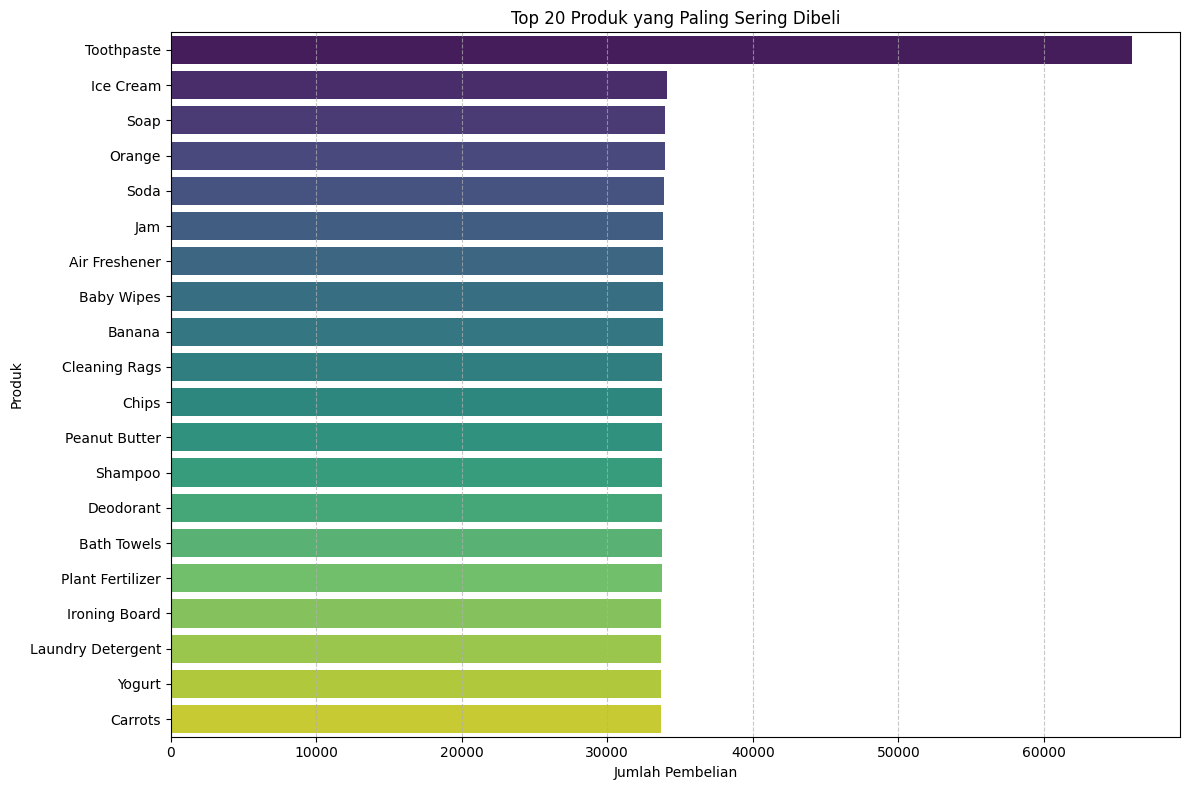

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert to Pandas DataFrame for visualization
top_20_items_pd = top_20_items.toPandas()

plt.figure(figsize=(12, 8))
sns.barplot(x='count', y='Item', data=top_20_items_pd, palette='viridis')
plt.title('Top 20 Produk yang Paling Sering Dibeli')
plt.xlabel('Jumlah Pembelian')
plt.ylabel('Produk')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 11. Analisis Lebih Lanjut: Top Rules Berdasarkan Lift dan Confidence

#### 11.1. Top Rules Berdasarkan Lift Tertinggi per Segmen

In [ ]:
from pyspark.sql.functions import col

print("\n--- Menampilkan Top Rules Berdasarkan Lift Tertinggi per Segmen ---")

for (season, discount_applied), data_dict in high_lift_rules_by_segment.items():
    rules_df = data_dict['rules'] # Extract the actual DataFrame
    if rules_df is not None and rules_df.count() > 0:
        discount_status_str = 'Ya' if discount_applied == 1 else 'Tidak'
        print(f"\nSegmen: Musim {season}, Diskon: {discount_status_str}")
        print("Top 10 Aturan Asosiasi (diurutkan berdasarkan lift menurun):")
        rules_df.orderBy(col("lift").desc()).show(10, truncate=False)
    else:
        discount_status_str = 'Ya' if discount_applied == 1 else 'Tidak'
        print(f"\nTidak ada aturan asosiasi dengan nilai lift lebih besar dari 1.0 untuk segmen Musim {season}, Diskon: {discount_status_str}.")

print("Analisis Top Rules berdasarkan Lift Selesai.")


--- Menampilkan Top Rules Berdasarkan Lift Tertinggi per Segmen ---

Segmen: Musim Summer, Diskon: Tidak
Top 10 Aturan Asosiasi (diurutkan berdasarkan lift menurun):
+---------------+---------------+--------------------+------------------+---------------------+
|antecedent     |consequent     |confidence          |lift              |support              |
+---------------+---------------+--------------------+------------------+---------------------+
|[Soda]         |[Spinach]      |0.04363803399173174 |1.0458449338316333|0.0019048000962425312|
|[Spinach]      |[Soda]         |0.04565112926477655 |1.0458449338316331|0.0019048000962425312|
|[Orange]       |[Apple]        |0.043132530120481925|1.041991672186445 |0.0017945221959337532|
|[Apple]        |[Orange]       |0.04335190118672802 |1.041991672186445 |0.0017945221959337532|
|[Air Freshener]|[Mop]          |0.043353293413173656|1.0323237792736324|0.0018145727232626219|
|[Mop]          |[Air Freshener]|0.04320840296013368 |1.032323779

#### 11.2. Top Rules Berdasarkan Confidence Tertinggi per Segmen

In [ ]:
from pyspark.sql.functions import col

print("\n--- Menampilkan Top Rules Berdasarkan Confidence Tertinggi per Segmen ---")

for (season, discount_applied), data_dict in high_lift_rules_by_segment.items():
    rules_df = data_dict['rules'] # Ekstrak DataFrame dari dictionary
    if rules_df is not None and rules_df.count() > 0:
        discount_status_str = 'Ya' if discount_applied == 1 else 'Tidak'
        print(f"\nSegmen: Musim {season}, Diskon: {discount_status_str}")
        print("Top 10 Aturan Asosiasi (diurutkan berdasarkan confidence menurun):")
        rules_df.orderBy(col("confidence").desc()).show(10, truncate=False)
    else:
        discount_status_str = 'Ya' if discount_applied == 1 else 'Tidak'
        print(f"\nTidak ada aturan asosiasi dengan nilai lift lebih besar dari 1.0 untuk segmen Musim {season}, Diskon: {discount_status_str}.")

print("Analisis Top Rules berdasarkan Confidence Selesai.")


--- Menampilkan Top Rules Berdasarkan Confidence Tertinggi per Segmen ---

Segmen: Musim Summer, Diskon: Tidak
Top 10 Aturan Asosiasi (diurutkan berdasarkan confidence menurun):
+---------------+---------------+--------------------+------------------+---------------------+
|antecedent     |consequent     |confidence          |lift              |support              |
+---------------+---------------+--------------------+------------------+---------------------+
|[Spinach]      |[Soda]         |0.04565112926477655 |1.0458449338316331|0.0019048000962425312|
|[Rice]         |[Salmon]       |0.04410011918951132 |1.0232376573424926|0.0018546737779203592|
|[Toilet Paper] |[Soda]         |0.04409638554216867 |1.0102265193064404|0.0018346232505914906|
|[Soda]         |[Spinach]      |0.04363803399173174 |1.0458449338316333|0.0019048000962425312|
|[Mop]          |[Cleaning Rags]|0.043447123418476966|1.0296421161193252|0.0018245979869270562|
|[Air Freshener]|[Mop]          |0.043353293413173656

### 12. Ringkasan Insight Bisnis dan Rekomendasi Bundling Produk

Dari analisis *association rules* yang telah kita lakukan, berikut adalah rangkuman *insight* bisnis dan rekomendasi *bundling* produk, dengan mempertimbangkan metrik *lift* dan *confidence* serta perbandingan pola antar segmen:

#### Insight Umum dari Aturan Lift Tinggi:

*   **Produk Komplementer:** Aturan dengan *lift* tinggi sering kali menunjukkan pembelian produk-produk komplementer. Misalnya, produk pembersih (Air Freshener, Mop, Cleaning Rags) sering dibeli bersama, begitu juga dengan makanan tertentu (Orange, Apple). Ini menunjukkan perilaku belanja terencana atau kebutuhan rumah tangga yang saling terkait.
*   **Potensi *Cross-Selling*:** *Lift* yang tinggi mengindikasikan bahwa pembelian satu item sangat meningkatkan kemungkinan pembelian item lain, lebih dari yang diharapkan secara acak. Ini adalah peluang besar untuk strategi *cross-selling*.
*   **Kenyamanan Pelanggan:** Bundling produk-produk yang sering dibeli bersama akan meningkatkan kenyamanan belanja bagi pelanggan, menghemat waktu mereka, dan berpotensi meningkatkan kepuasan.

#### Insight Umum dari Aturan Confidence Tinggi:

*   **Pola Pembelian Konsisten:** Aturan dengan *confidence* tinggi menunjukkan bahwa ketika *antecedent* dibeli, *consequent* hampir selalu dibeli. Ini adalah pola yang sangat dapat diandalkan untuk rekomendasi atau penempatan produk.
*   **Bundling Kuat:** Produk dengan *confidence* tinggi sangat cocok untuk *bundling* langsung, karena kemungkinan pelanggan akan membeli keduanya sangat tinggi.

#### Rekomendasi Bundling Produk Berdasarkan Pola Umum:

1.  **"Healthy Refreshment Bundle"**: **Orange + Apple**. Dapat ditawarkan sebagai kombinasi untuk sarapan atau snack sehat.
2.  **"Home Cleaning Essentials"**: **Air Freshener + Mop** atau **Mop + Cleaning Rags**. Bundling ini sangat logis untuk kebutuhan kebersihan rumah tangga.
3.  **"Meal Prep Duo"**: **Salmon + Rice** atau **Beef + Cereal**. Menawarkan kombinasi untuk persiapan makan.
4.  **"Personal Care Combo"**: **Diapers + Dish Soap** atau **Shaving Cream + Shampoo**. Produk-produk kebutuhan pribadi yang sering dibeli bersama.

### 13. Perbandingan Pola Berdasarkan Segmen (Musim & Diskon)

#### Pola Berdasarkan Musim:

*   **Musim Panas (Summer):** Cenderung memiliki jumlah aturan asosiasi dengan *lift* tinggi paling banyak, baik dengan maupun tanpa diskon. Ini bisa mengindikasikan aktivitas belanja yang lebih beragam atau pembelian musiman yang kuat (misalnya, produk-produk terkait liburan atau kegiatan di luar ruangan).
    *   **Contoh Khusus**: Aturan "Orange dan Apple" memiliki lift tertinggi di musim panas tanpa diskon, menunjukkan ini adalah pola belanja alami yang kuat tanpa insentif diskon.
*   **Musim Gugur (Fall):** Menunjukkan jumlah aturan yang sedikit lebih rendah dibandingkan Musim Panas dan Dingin. Pola pembelian mungkin lebih stabil atau berfokus pada kebutuhan kembali ke sekolah/bekerja atau persiapan untuk musim dingin.
*   **Musim Semi (Spring):** Mirip dengan Musim Gugur dalam jumlah aturan. Mungkin terkait dengan pembersihan musim semi, persiapan liburan, atau awal musim tanam.
*   **Musim Dingin (Winter):** Menunjukkan banyak aturan, terutama tanpa diskon. Mungkin ada peningkatan pembelian untuk persiapan liburan akhir tahun, kumpul keluarga, atau produk-produk kenyamanan rumah tangga di tengah cuaca dingin.
    *   **Contoh Khusus**: Aturan spesifik untuk musim dingin mungkin melibatkan produk-produk seperti kopi, teh hangat, atau bahan makanan untuk hidangan khusus.

#### Pola Berdasarkan Status Diskon (`Discount_Applied`):

*   **Dengan Diskon (Discount_Applied = 1):** Umumnya, jumlah aturan asosiasi dengan *lift* tinggi sedikit lebih rendah atau setara dibandingkan tanpa diskon. Ini bisa berarti bahwa diskon mungkin mendorong pembelian item-item tertentu tetapi tidak secara drastis mengubah pola asosiasi produk inti. Pelanggan mungkin membeli item diskon sebagai pembelian tunggal daripada sebagai bagian dari *bundle* yang lebih besar yang digerakkan oleh asosiasi alami.
    *   **Insight**: Diskon mungkin efektif untuk menarik perhatian pada produk individual, tetapi untuk *bundling* yang lebih dalam, fokus pada hubungan produk alami yang memiliki *lift* tinggi bahkan tanpa diskon mungkin lebih kuat.
*   **Tanpa Diskon (Discount_Applied = 0):** Menunjukkan jumlah aturan yang relatif tinggi dan seringkali *lift* yang sedikit lebih tinggi. Ini mengindikasikan pola pembelian alami pelanggan ketika tidak ada promosi khusus yang memengaruhi keputusan mereka. Aturan ini sangat berharga karena mencerminkan preferensi inti pelanggan.
    *   **Insight**: Untuk mendorong peningkatan nilai transaksi, strategi *bundling* harus lebih banyak didasarkan pada aturan asosiasi yang kuat secara organik (terlihat tanpa diskon), kemudian diskon dapat digunakan sebagai akselerator untuk *bundle* tersebut.

#### Kesimpulan Perbandingan:

*   **Musim memiliki pengaruh yang lebih terlihat** pada jumlah dan jenis aturan asosiasi dibandingkan dengan penerapan diskon. Ini menyarankan bahwa strategi pemasaran dan *bundling* harus sangat disesuaikan dengan perubahan musim.
*   Meskipun diskon penting, **pola pembelian alami (tanpa diskon) adalah dasar yang kuat** untuk mengembangkan strategi *bundling* yang berkelanjutan. Diskon dapat diterapkan untuk memperkuat *bundle* yang sudah terbukti kuat secara organik.
*   **Fokus pada *cross-selling* produk komplementer** yang muncul dengan *lift* dan *confidence* tinggi di berbagai segmen.

Dengan memahami pola-pola ini, bisnis dapat membuat keputusan yang lebih terinformasi mengenai penempatan produk, promosi, dan strategi *bundling* untuk memaksimalkan penjualan dan kepuasan pelanggan di setiap skenario.

### Mencari Aturan Bundling yang Melibatkan 'Toothpaste'

Karena 'Toothpaste' adalah salah satu produk yang paling sering dibeli, mari kita secara khusus mencari aturan asosiasi yang melibatkan 'Toothpaste' sebagai *antecedent* atau *consequent* di setiap segmen.

In [ ]:
from pyspark.sql.functions import array_contains, col

print("\n--- Aturan Asosiasi yang Melibatkan 'Toothpaste' per Segmen ---")

for (season, discount_applied), data_dict in high_lift_rules_by_segment.items():
    rules_df = data_dict['rules'] # Extract the DataFrame from the dictionary
    if rules_df is not None and rules_df.count() > 0:
        discount_status_str = 'Ya' if discount_applied == 1 else 'Tidak'

        # Filter rules where 'Toothpaste' is either in antecedent or consequent
        toothpaste_rules = rules_df.filter(
            array_contains(col("antecedent"), "Toothpaste") |
            array_contains(col("consequent"), "Toothpaste")
        )

        if toothpaste_rules.count() > 0:
            print(f"\nSegmen: Musim {season}, Diskon: {discount_status_str}")
            print(f"Ditemukan {toothpaste_rules.count()} aturan melibatkan 'Toothpaste':")
            toothpaste_rules.orderBy(col("lift").desc()).show(truncate=False)
        else:
            print(f"\nTidak ada aturan asosiasi yang melibatkan 'Toothpaste' untuk segmen Musim {season}, Diskon: {discount_status_str}.")
    else:
        discount_status_str = 'Ya' if discount_applied == 1 else 'Tidak'
        print(f"\nTidak ada aturan asosiasi dengan nilai lift lebih besar dari 1.0 untuk segmen Musim {season}, Diskon: {discount_status_str}.")

print("Pencarian aturan yang melibatkan 'Toothpaste' selesai.")


--- Aturan Asosiasi yang Melibatkan 'Toothpaste' per Segmen ---

Tidak ada aturan asosiasi yang melibatkan 'Toothpaste' untuk segmen Musim Summer, Diskon: Tidak.

Tidak ada aturan asosiasi yang melibatkan 'Toothpaste' untuk segmen Musim Fall, Diskon: Ya.

Tidak ada aturan asosiasi yang melibatkan 'Toothpaste' untuk segmen Musim Summer, Diskon: Ya.

Tidak ada aturan asosiasi yang melibatkan 'Toothpaste' untuk segmen Musim Fall, Diskon: Tidak.

Tidak ada aturan asosiasi yang melibatkan 'Toothpaste' untuk segmen Musim Spring, Diskon: Tidak.

Tidak ada aturan asosiasi yang melibatkan 'Toothpaste' untuk segmen Musim Spring, Diskon: Ya.

Tidak ada aturan asosiasi yang melibatkan 'Toothpaste' untuk segmen Musim Winter, Diskon: Ya.

Tidak ada aturan asosiasi yang melibatkan 'Toothpaste' untuk segmen Musim Winter, Diskon: Tidak.
Pencarian aturan yang melibatkan 'Toothpaste' selesai.


### 14. Visualisasi Perbandingan Metrik Aturan Asosiasi per Segmen

Untuk mendapatkan pemahaman yang lebih baik tentang bagaimana metrik aturan asosiasi bervariasi antar segmen, kita akan memvisualisasikan `comparison_df`.

/tmp/ipykernel_8101/1713649721.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Segment', y='Avg_Lift', data=comparison_df, palette='viridis')
/tmp/ipykernel_8101/1713649721.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Segment', y='Avg_Confidence', data=comparison_df, palette='magma')


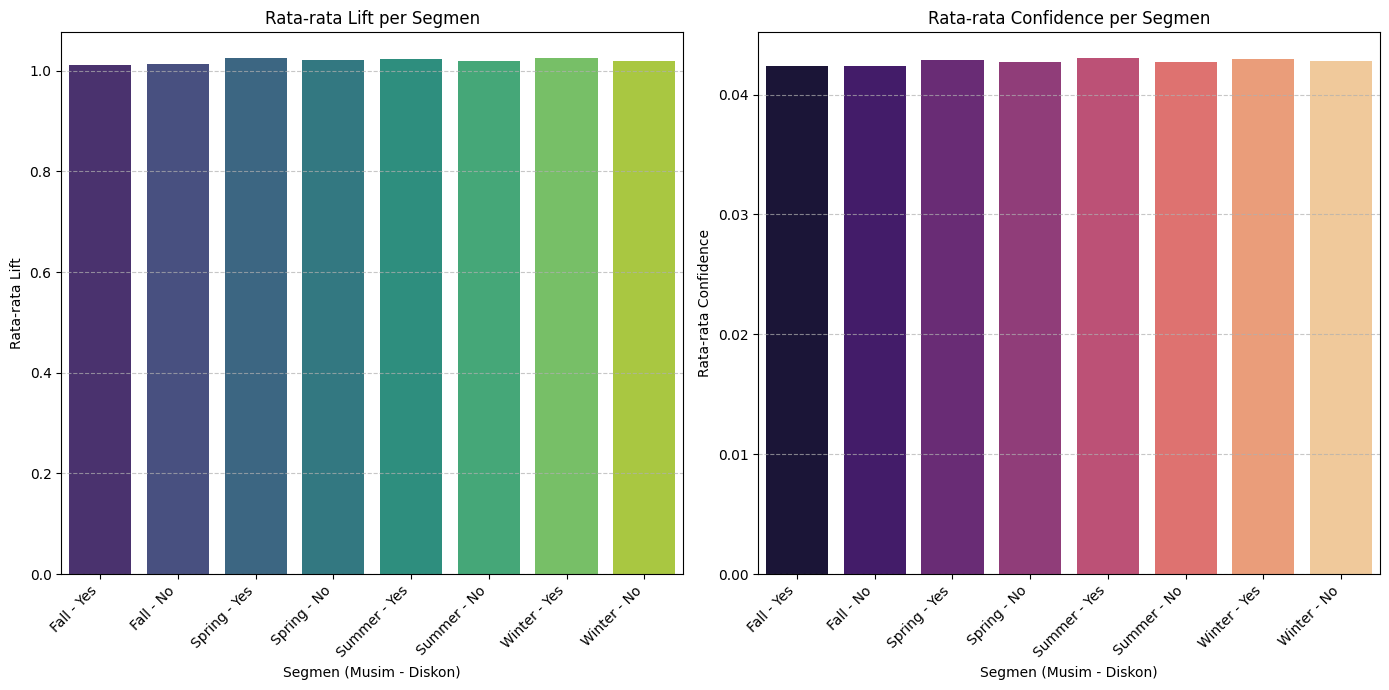

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Pastikan comparison_df adalah Pandas DataFrame
# Jika belum, asumsikan sudah dibuat di sel e0efac4f dan diimpor
# comparison_df = pd.read_csv('path_to_your_comparison_data.csv') # Jika perlu load ulang

# Gabungkan 'Season' dan 'Discount_Applied' untuk label yang lebih jelas
comparison_df['Segment'] = comparison_df['Season'] + ' - ' + comparison_df['Discount_Applied']

plt.figure(figsize=(14, 7))

# Bar chart untuk Average Lift
plt.subplot(1, 2, 1) # 1 baris, 2 kolom, plot pertama
sns.barplot(x='Segment', y='Avg_Lift', data=comparison_df, palette='viridis')
plt.title('Rata-rata Lift per Segmen')
plt.xlabel('Segmen (Musim - Diskon)')
plt.ylabel('Rata-rata Lift')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Bar chart untuk Average Confidence
plt.subplot(1, 2, 2) # 1 baris, 2 kolom, plot kedua
sns.barplot(x='Segment', y='Avg_Confidence', data=comparison_df, palette='magma')
plt.title('Rata-rata Confidence per Segmen')
plt.xlabel('Segmen (Musim - Diskon)')
plt.ylabel('Rata-rata Confidence')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### Visualisasi Jumlah Aturan (Number of Rules) per Musim

/tmp/ipykernel_8101/4201511846.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Season', y='Number_of_Rules', data=rules_per_season, palette='coolwarm')


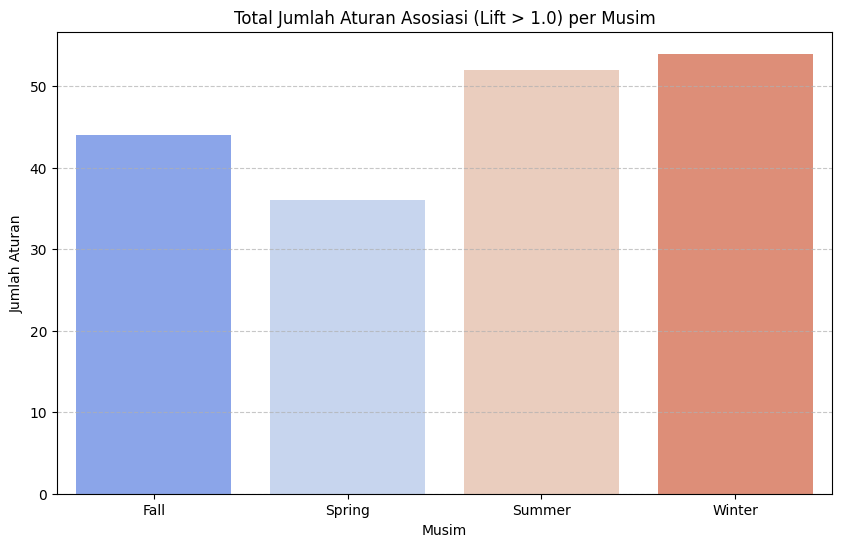

In [ ]:
# Agregasi jumlah aturan per musim
rules_per_season = comparison_df.groupby('Season')['Number_of_Rules'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Season', y='Number_of_Rules', data=rules_per_season, palette='coolwarm')
plt.title('Total Jumlah Aturan Asosiasi (Lift > 1.0) per Musim')
plt.xlabel('Musim')
plt.ylabel('Jumlah Aturan')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Heatmap Hubungan Musim, Diskon, dan Rata-rata Lift

**Mengapa rata-rata Lift itu penting?**

Metrik *Lift* adalah salah satu indikator terpenting dalam analisis aturan asosiasi. Nilai *Lift* diinterpretasikan sebagai berikut:
*   **Lift > 1:** Menunjukkan bahwa kemunculan *antecedent* meningkatkan kemungkinan kemunculan *consequent*. Artinya, ada hubungan positif antara kedua item tersebut, dan mereka dibeli bersama lebih sering daripada yang diharapkan secara acak. Semakin tinggi nilai *Lift* (jauh di atas 1), semakin kuat hubungan positif tersebut, menjadikannya kandidat yang sangat baik untuk strategi *bundling* atau *cross-selling*.
*   **Lift = 1:** Menunjukkan bahwa kemunculan *antecedent* tidak memiliki efek pada kemunculan *consequent*. Item-item tersebut dibeli bersama secara independen.
*   **Lift < 1:** Menunjukkan bahwa kemunculan *antecedent* menurunkan kemungkinan kemunculan *consequent*. Ada hubungan negatif antara kedua item tersebut.

Dengan membandingkan rata-rata *Lift* antar segmen, kita bisa mengidentifikasi segmen mana (kombinasi musim dan diskon) yang memiliki pola pembelian produk terkait yang paling kuat secara inheren. Ini sangat berharga untuk menargetkan kampanye pemasaran atau rekomendasi *bundling* di mana pelanggan secara alami cenderung membeli produk-produk komplementer.

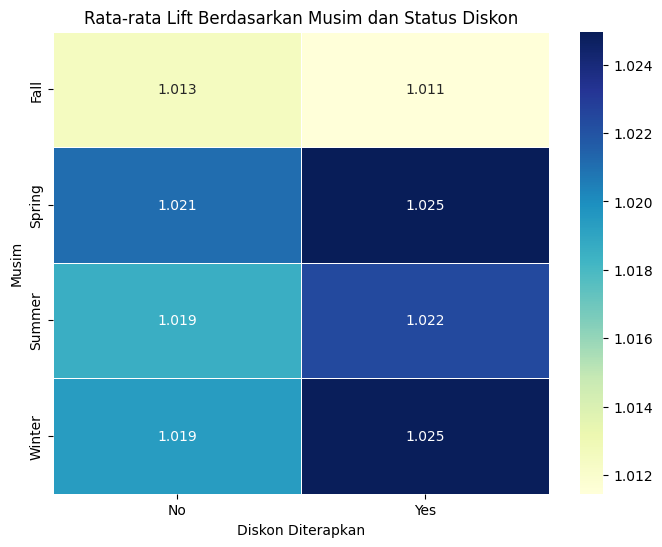

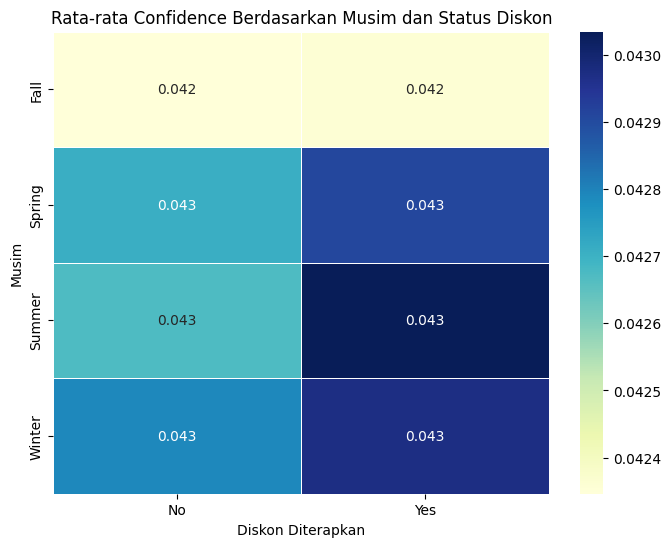

In [ ]:
# Pivot DataFrame untuk heatmap
heatmap_data = comparison_df.pivot_table(index='Season', columns='Discount_Applied', values='Avg_Lift')

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt=".3f", linewidths=.5)
plt.title('Rata-rata Lift Berdasarkan Musim dan Status Diskon')
plt.xlabel('Diskon Diterapkan')
plt.ylabel('Musim')
plt.show()

# Jika ingin melihat heatmap untuk Confidence juga
heatmap_data_confidence = comparison_df.pivot_table(index='Season', columns='Discount_Applied', values='Avg_Confidence')

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data_confidence, annot=True, cmap='YlGnBu', fmt=".3f", linewidths=.5)
plt.title('Rata-rata Confidence Berdasarkan Musim dan Status Diskon')
plt.xlabel('Diskon Diterapkan')
plt.ylabel('Musim')
plt.show()